In [54]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

In [55]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        def conv(in_c, out_c): 
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )
        self.down1 = conv(4, 32)
        self.down2 = conv(32, 64)
        self.down3 = conv(64, 128)
        self.middle = conv(128, 256)
        self.up3 = conv(256 + 128, 128)
        self.up2 = conv(128 + 64, 64)
        self.up1 = conv(64 + 32, 32)
        self.out = nn.Conv2d(32, 1, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        xm = self.middle(self.pool(x3))
        x = F.interpolate(xm, scale_factor=2, mode='bilinear', align_corners=False)
        x = self.up3(torch.cat([x, x3], dim=1))
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x = self.up2(torch.cat([x, x2], dim=1))
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x = self.up1(torch.cat([x, x1], dim=1))
        return torch.sigmoid(self.out(x))


In [56]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = UNet().to(device)
model.load_state_dict(torch.load('unet_model_v9.pt', map_location=device))
model.eval()


Using device: cpu


C:\Users\Puneet\AppData\Local\Temp\ipykernel_28604\606338875.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('unet_model_v9.pt', map_loc

UNet(
  (down1): Sequential(
    (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (down2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (down3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (middle): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (up3): Sequential(
    (0): Conv2d(384, 128, kernel_s

In [57]:
patient_folder = './2_BABUL KALITA 66 M_MR_head^Saravana 1_1_nii'

# Find nii files in that folder
all_nii_files = [os.path.join(patient_folder, f) for f in os.listdir(patient_folder) if f.endswith('.nii')]
all_nii_files


['./2_BABUL KALITA 66 M_MR_head^Saravana 1_1_nii\\t1c.nii',
 './2_BABUL KALITA 66 M_MR_head^Saravana 1_1_nii\\t1n.nii',
 './2_BABUL KALITA 66 M_MR_head^Saravana 1_1_nii\\t2.nii',
 './2_BABUL KALITA 66 M_MR_head^Saravana 1_1_nii\\t2_flair.nii']

In [58]:
modalities = ['t1n', 't2', 't1c', 't2_flair']
modality_paths = {}
for mod in modalities:
    for f in all_nii_files:
        if mod in f.lower():
            modality_paths[mod] = f

print(modality_paths)


{'t1n': './2_BABUL KALITA 66 M_MR_head^Saravana 1_1_nii\\t1n.nii', 't2': './2_BABUL KALITA 66 M_MR_head^Saravana 1_1_nii\\t2_flair.nii', 't1c': './2_BABUL KALITA 66 M_MR_head^Saravana 1_1_nii\\t1c.nii', 't2_flair': './2_BABUL KALITA 66 M_MR_head^Saravana 1_1_nii\\t2_flair.nii'}


In [59]:
def load_nifti_image(path):
    img = nib.load(path)
    data = img.get_fdata()
    return data

def normalize(volume):
    mean = np.mean(volume)
    std = np.std(volume)
    return (volume - mean) / (std + 1e-5)

# Load all 4 modalities
volumes = []
for mod in modalities:
    vol = load_nifti_image(modality_paths[mod])
    vol = normalize(vol)
    volumes.append(vol)

# Shape = (4, H, W, D)
volumes = np.stack(volumes, axis=0)
print("Stacked volume shape:", volumes.shape)


Stacked volume shape: (4, 320, 270, 27)


In [60]:
_, H, W, D = volumes.shape
middle_slice = D // 2

# This is 2D image with 4 channels
slice_2d = volumes[:, :, :, middle_slice]
print("Slice shape (C, H, W):", slice_2d.shape)


Slice shape (C, H, W): (4, 320, 270)


In [61]:
def pad_to_multiple(img, factor=8):
    C, H, W = img.shape
    pad_H = (factor - H % factor) % factor
    pad_W = (factor - W % factor) % factor
    pad = ((0, 0), (0, pad_H), (0, pad_W))
    padded_img = np.pad(img, pad, mode='constant')
    return padded_img

slice_2d_padded = pad_to_multiple(slice_2d, factor=8)
print("Padded shape:", slice_2d_padded.shape)


Padded shape: (4, 320, 272)


In [62]:
# Shape (1, 4, H, W)
input_tensor = torch.from_numpy(slice_2d_padded).unsqueeze(0).float().to(device)
print(input_tensor.shape) 


torch.Size([1, 4, 320, 272])


In [67]:
with torch.no_grad():
    output = model(input_tensor)
    print(output.shape)  # Should be (1, 1, H, W) or similar
    output_mask = output.squeeze().cpu().numpy()
    predicted_mask = (output_mask > 0.4).astype(np.uint8)

# Confirm
print("Predicted mask shape:", predicted_mask.shape)


torch.Size([1, 1, 320, 272])
Predicted mask shape: (320, 272)


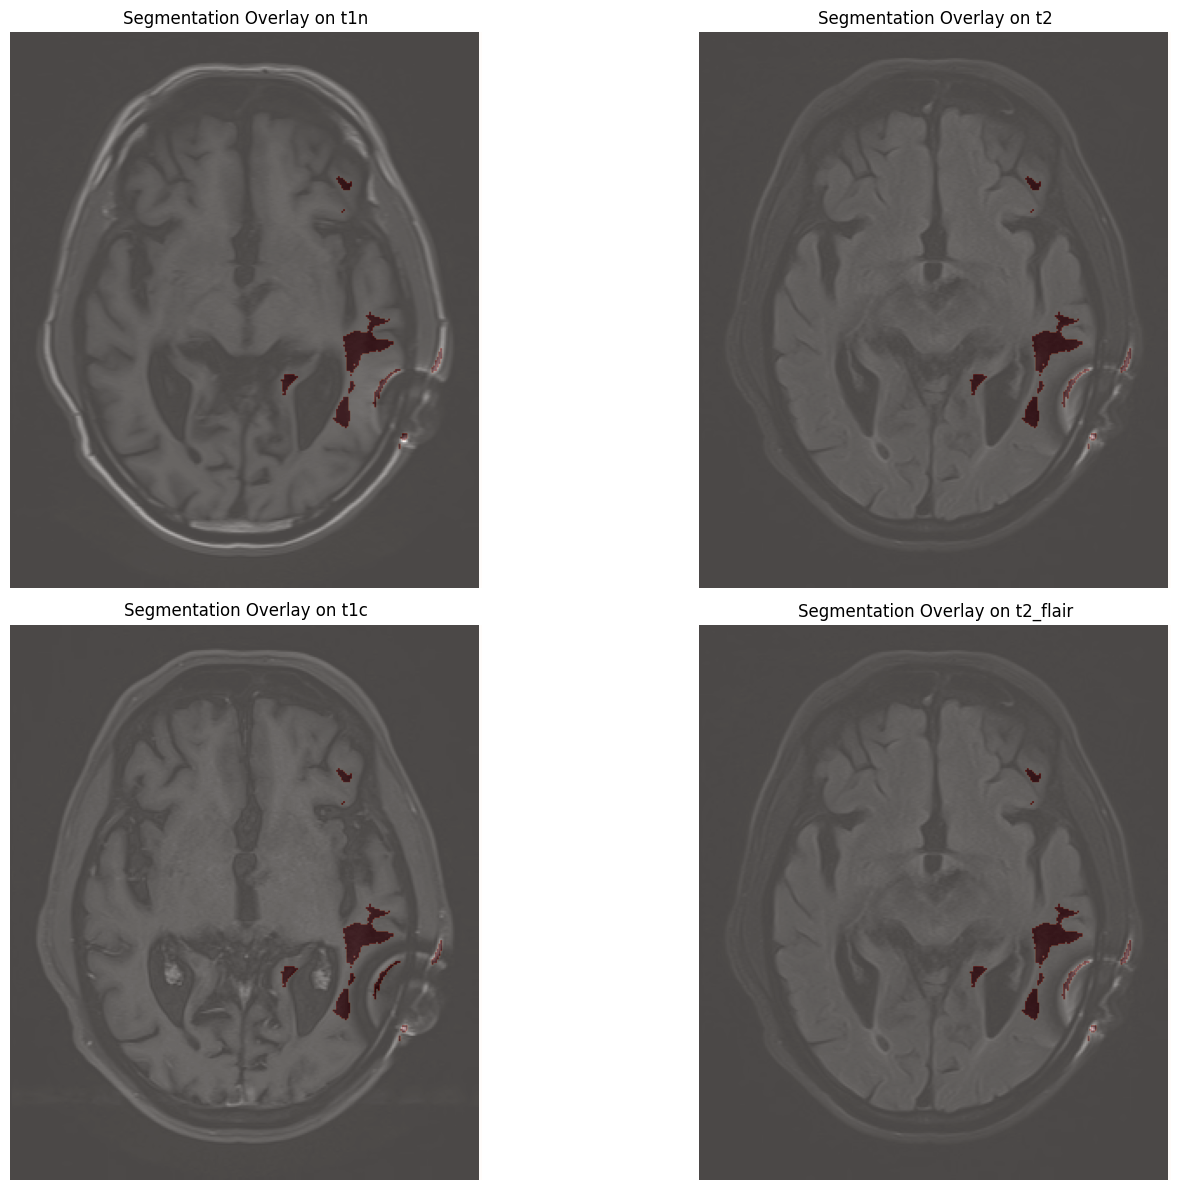

In [69]:
modality_names = ['t1n', 't2', 't1c', 't2_flair']
num_modalities = len(modality_names)

plt.figure(figsize=(16, 12))

for i in range(num_modalities):
    plt.subplot(2, 2, i + 1)
    background_slice = slice_2d[i, :, :]
    plt.imshow(background_slice, cmap='gray')
    plt.imshow(predicted_mask, cmap='Reds', alpha=0.3)
    plt.title(f'Segmentation Overlay on {modality_names[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()
